### Import Modules

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


import seaborn as sns
import matplotlib.pyplot as plt


### Test 1: Logistic Regression only predicting using reviews represented w/ GloVE embeddings


In [40]:
train_df = pd.read_csv("train.tsv", sep="\t", header=None)
val_df   = pd.read_csv("val.tsv", sep="\t", header=None)
test_df  = pd.read_csv("test.tsv", sep="\t", header=None)

# split my data into labels (first col) and features (rest of cols)
y_train = train_df.iloc[:, 0]
X_train = train_df.iloc[:, 1:]

y_val = val_df.iloc[:, 0]
X_val = val_df.iloc[:, 1:]

y_test = test_df.iloc[:, 0]
X_test = test_df.iloc[:, 1:]

In [41]:
# only ~ 2.4% nominated, so label 1 is minority
print(y_train.value_counts()) 

model = LogisticRegression(
    class_weight="balanced", # gives more importance to class 1, best pic nominated (minority class)
                            # penalizes mistakes on class 1 more heavily, ensure model does not just "predict 0 every time"
    max_iter=1000, 
    solver="lbfgs", 
    C=100)


0
0.0    9751
1.0     241
Name: count, dtype: int64


In [42]:
# train
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
print("Training accuracy:", accuracy_score(y_train, train_pred))


# validate
val_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

# test
test_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print(classification_report(y_test, test_pred))

Training accuracy: 0.8264611689351481
Validation Accuracy: 0.8182546036829463
Test Accuracy: 0.8070456365092074
              precision    recall  f1-score   support

         0.0       0.99      0.81      0.89      1212
         1.0       0.09      0.59      0.15        37

    accuracy                           0.81      1249
   macro avg       0.54      0.70      0.52      1249
weighted avg       0.96      0.81      0.87      1249



Acccuracy is fairly high, 81.8% for validation and 80.7% for testing. However, this is misleading. There are only a small number of total films which have nominted for best picture, so the model learns to just predict "no" on everything. F1-score is very low (0.15) which is bad - this means low precision and low recall.  

Precision: How many of the positive predictions made by the model are actually correct?  
Recall: How many of the actual positive cases were correctly identified by the model.  

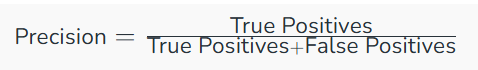  
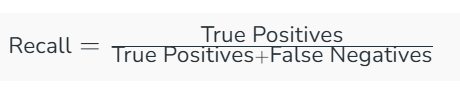  

[[1002  222]
 [   5   20]]


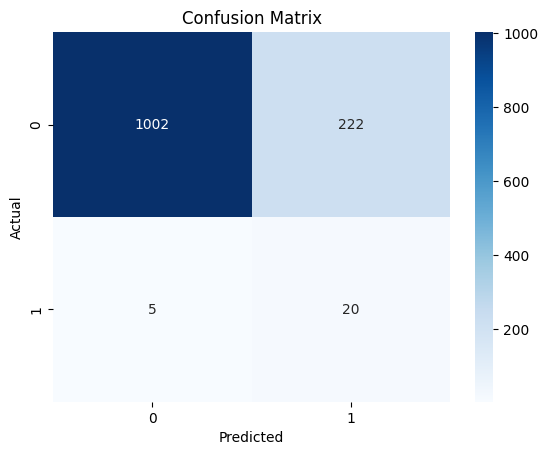

In [ ]:
# Confusion matrix format:
# [[TN, FP],
# [FN, TP]]

cm = confusion_matrix(y_val, val_pred)
print(cm)


# make plot to visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Model overpredicts on 1, there are 222 instances of predicting 1 when it should be 0.

In [ ]:
# Test a bunch of different C vals, inverse of regularization strength
# Smaller C -> stronger regularization (penalize wrong predictions more to prevent overfitting)
# Larger C -> weaker regularization (penalize less, fit closer to training data)

C_values = [0.01, 0.1, 0.5, 1, 5, 10]

best_C = None
best_f1 = -1
best_model = None

for C in C_values:
    model = LogisticRegression(
        C=C,
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs"
    )
    
    # train on training set
    model.fit(X_train, y_train)
    
    # evaluate on validation set
    val_pred = model.predict(X_val)
    f1 = f1_score(y_val, val_pred, average="binary")  
    
    print(f"C={C} | Val F1={f1:.4f}")
    
    # find best C val and f1 score
    if f1 > best_f1:
        best_f1 = f1
        best_C = C
        best_model = model

print("\nBest C:", best_C)
print("Best Validation F1:", best_f1)

C=0.01 | Val F1=0.0974
C=0.1 | Val F1=0.1268
C=0.5 | Val F1=0.1329
C=1 | Val F1=0.1379
C=5 | Val F1=0.1502
C=10 | Val F1=0.1566

Best C: 10
Best Validation F1: 0.15658362989323843


### Test 2: Logistic Regression only predicting using reviews represented w/ TF-IDF (Term Frequency–Inverse Document Frequency) 

https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/?_x_tr_hist=true  

Highlight terms that are both frequent and distinctive.  

**Term frequency**: Measures how often a word appears in a document. A higher frequency suggests greater importance. If a term appears frequently in a document, it is likely relevant to the document’s content.  
**Inverse document frequency**: Reduces the weight of common words across multiple documents while increasing the weight of rare words. If a term appears in fewer documents, it is more likely to be meaningful and specific.


In [47]:
master_df = pd.read_csv("master_df.tsv", sep="\t")
# print(master_df.columns)
# print(master_df.head())

In [49]:
# count total number of best_picture_nom in the dataset
# only 303 in this case...not very many
print(master_df["best_picture_nom"].sum())

303


In [50]:
X = master_df["review_content"]
y = master_df["best_picture_nom"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [51]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,4),   # length of word combinations to capture more context. here, include 1-4 words.
    min_df=2,            # removes noise words
    max_df=0.9,          # removes overly common words
    max_features=10000  # more signal capacity
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

In [52]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs"
)

model.fit(X_train_tfidf, y_train)

val_pred = model.predict(X_val_tfidf)
test_pred = model.predict(X_test_tfidf)

print("Validation Report:\n")
print(classification_report(y_val, val_pred))

print("\nTest Confusion Matrix:\n")
print(confusion_matrix(y_test, test_pred))

Validation Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1828
           1       0.22      0.47      0.30        45

    accuracy                           0.95      1873
   macro avg       0.60      0.71      0.64      1873
weighted avg       0.97      0.95      0.96      1873


Test Confusion Matrix:

[[1750   78]
 [  17   29]]


F1 score greatly improved from ~0.15 -> 0.3

In [ ]:
# Search for a better threshold to boost f1-score, in this case using 0.6 can get the score to 0.38 instead of 0.3

val_probs = model.predict_proba(X_val_tfidf)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_thresh = 0
best_f1 = 0

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    f1 = f1_score(y_val, val_pred)
    
    print(f"Threshold={t:.2f} | F1={f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("\nBest threshold:", best_thresh)
print("Best validation F1:", best_f1)

Threshold=0.10 | F1=0.1024
Threshold=0.15 | F1=0.1441
Threshold=0.20 | F1=0.1834
Threshold=0.25 | F1=0.2000
Threshold=0.30 | F1=0.2294
Threshold=0.35 | F1=0.2468
Threshold=0.40 | F1=0.2549
Threshold=0.45 | F1=0.2840
Threshold=0.50 | F1=0.3022
Threshold=0.55 | F1=0.3419
Threshold=0.60 | F1=0.3800
Threshold=0.65 | F1=0.3294
Threshold=0.70 | F1=0.2933
Threshold=0.75 | F1=0.2941
Threshold=0.80 | F1=0.2414
Threshold=0.85 | F1=0.1132

Best threshold: 0.6000000000000002
Best validation F1: 0.38


### Test 3 - Logistic Regression which considers multiple features
* Year
* Budget
* Revenue
* Runtime
* Tomatometer_rating
* Audience_rating
* Review_content (original)

In [55]:
df = pd.read_csv("master_df.tsv", sep="\t")
# print(df.columns)
df.columns = df.columns.str.strip()

In [56]:
X = df
y = df["best_picture_nom"]

text_col = "review_content"

num_cols = ["year", "budget", "revenue", "runtime",
            "tomatometer_rating", "audience_rating"]

cat_cols = ["director", "cast"]   # did not include genre

In [57]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")
df[text_col] = df[text_col].fillna("")

In [58]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [59]:
preprocess = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1,3), min_df=2), text_col),
    
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    
    ("num", StandardScaler(), num_cols)
])

In [60]:
model = Pipeline([
    ("features", preprocess),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        C=10,
    ))
])

In [61]:
model.fit(X_train, y_train)

# Validate
val_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

# Test
# test_pred = model.predict(X_test)
# print("Test Accuracy:", accuracy_score(y_test, test_pred))

print(confusion_matrix(y_val, val_pred))
print(classification_report(y_val, val_pred))

Validation Accuracy: 0.9749065670048052
[[1810   18]
 [  29   16]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1828
           1       0.47      0.36      0.41        45

    accuracy                           0.97      1873
   macro avg       0.73      0.67      0.70      1873
weighted avg       0.97      0.97      0.97      1873



In [62]:
val_probs = model.predict_proba(X_val)[:, 1]

best_f1 = 0
best_thresh = 0

for t in np.arange(0.1, 0.9, 0.01):
    val_pred = (val_probs >= t).astype(int)
    f1 = f1_score(y_val, val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

Best threshold: 0.3599999999999999
Best F1: 0.43010752688172044


In [63]:
# check what the false positives actually are 
false_positives = X_val[(y_val == 0) & (val_pred == 1)]
print(false_positives)

                      title  \
67                  Molière   
1762  A Brighter Summer Day   
3337    Catch Me If You Can   

                                         review_content  best_picture_nom  \
67    speculative pic on how gaul's answer to shakes...                 0   
1762  a brighter summer day stands as a massive achi...                 0   
3337  the chase is fun, amusing, and hosts a good se...                 0   

      year      budget      revenue  runtime           director  \
67    1978         0.0          0.0    260.0  Ariane Mnouchkine   
1762  1991         0.0          0.0    237.0        Edward Yang   
3337  2002  52000000.0  352114312.0    141.0   Steven Spielberg   

                                                   cast  tomatometer_rating  \
67    ['Philippe Caubère', 'Marie-Françoise Audollen...                69.0   
1762  ['Chang Chen', 'Lisa Yang', 'Elaine Jin', 'Che...               100.0   
3337  ['Leonardo DiCaprio', 'Tom Hanks', 'Christophe...     

In [ ]:
test_probs = model.predict_proba(X_test)[:, 1]
# adjust threshold as 0.36
test_pred = (test_probs >= 0.36).astype(int)

print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))


[[1800   28]
 [  20   26]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1828
           1       0.48      0.57      0.52        46

    accuracy                           0.97      1874
   macro avg       0.74      0.77      0.75      1874
weighted avg       0.98      0.97      0.98      1874

Test Accuracy: 0.9743863393810032


- Tested both just reviews & multiple features, ended up including multiple features as this boosted f1 score
- Tuned regularization strength & threshold
- Best c = 10, best threshold is 0.36, best f1-score (val) = 0.43

Final test accuracy is high (97.4%). Was able to boost f1-score to 0.52.

### Confusion matrix for validation data

[[1825    3]
 [  39    6]]


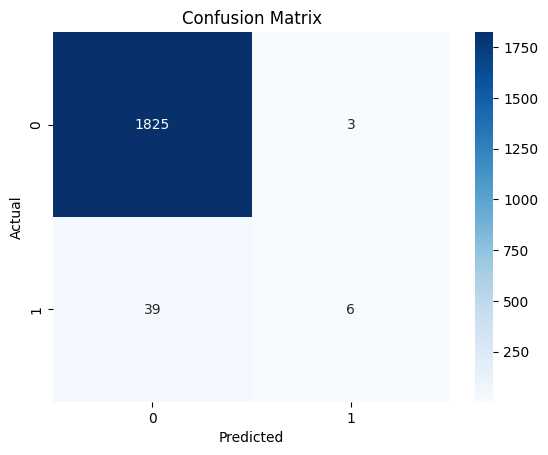

In [65]:
cm = confusion_matrix(y_val, val_pred)
print(cm)


# make plot to visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Confusion matrix for testing data

[[1800   28]
 [  20   26]]


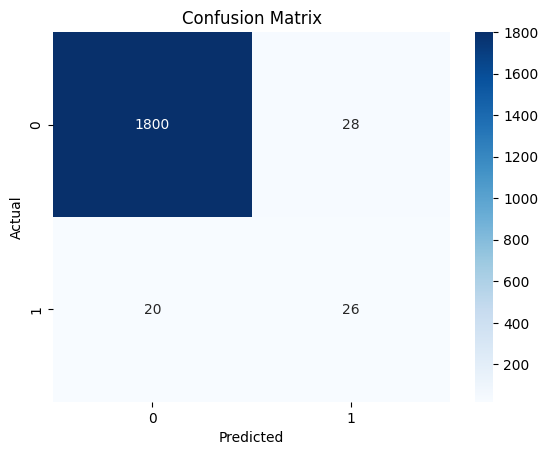

In [67]:
cm_test = confusion_matrix(y_test, test_pred)
print(cm_test)


# make plot to visualize confusion matrix
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

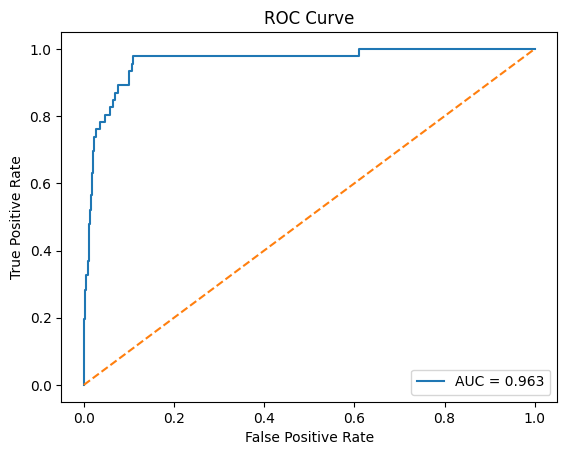

In [68]:
from sklearn.metrics import roc_curve, roc_auc_score
probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

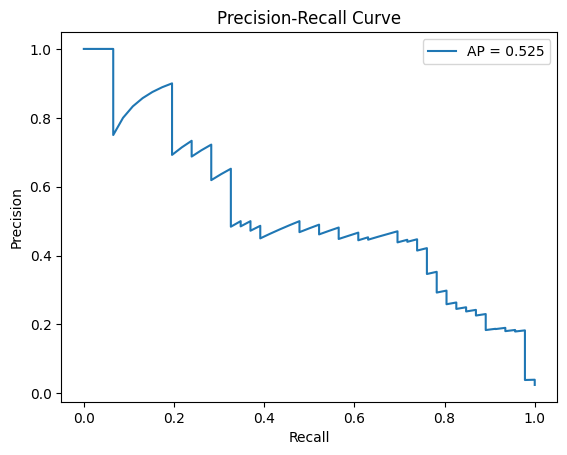

In [69]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)

plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()